In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
df = pd.read_csv("../../../course_assignments/homework8/state_data.csv")


In [5]:
print(df.shape)
display(df.head())
display(df.tail())

(52, 4)


,state,latitude,longitude,name
0,AK,63.588753,-154.493062,Alaska
1,AL,32.318231,-86.902298,Alabama
2,AR,35.201050,-91.831833,Arkansas
3,AZ,34.048928,-111.093731,Arizona
4,CA,36.778261,-119.417932,California


,state,latitude,longitude,name
47,VT,44.558803,-72.577841,Vermont
48,WA,47.751074,-120.740139,Washington
49,WI,43.784440,-88.787868,Wisconsin
50,WV,38.597626,-80.454903,West Virginia
51,WY,43.075968,-107.290284,Wyoming


In [6]:
first_state = df.iloc[0]["state"]
last_state = df.iloc[-1]["state"]
total_entries = len(df)
print(first_state, last_state, total_entries)

AK WY 52


In [7]:
median_lat = df["latitude"].median()
median_long = df["longitude"].median()

df["dist_to_med_lat"] = abs(df["latitude"] - median_lat)
df["dist_to_med_long"] = abs(df["longitude"] - median_long)

print(df.shape)

(52, 6)


In [8]:
closest_lat_state = df.loc[df["dist_to_med_lat"].idxmin(), "state"]
farthest_lat_state = df.loc[df["dist_to_med_lat"].idxmax(), "state"]
closest_long_state = df.loc[df["dist_to_med_long"].idxmin(), "state"]
farthest_long_state = df.loc[df["dist_to_med_long"].idxmax(), "state"]

print(closest_lat_state)
print(farthest_lat_state)
print(closest_long_state)
print(farthest_long_state)


CO
AK
IL
HI


In [9]:
# df.nunique() counts how many unique (different) values are in each column.
# This helps us quickly understand if a column has repeated values or many categories.

df.nunique()


state               52
latitude            52
longitude           45
name                52
dist_to_med_lat     51
dist_to_med_long    44
dtype: int64

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
diamonds = sns.load_dataset("diamonds")
print(diamonds.shape)
print(diamonds.head())
print(diamonds.tail())
print(diamonds.columns)

(53940, 10)
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      d

In [18]:
diamonds_clean = diamonds.dropna(axis=1)

print(diamonds_clean.shape)
print(diamonds_clean.head())
print(diamonds_clean.tail())
print(diamonds_clean.columns)

(53940, 10)
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      d

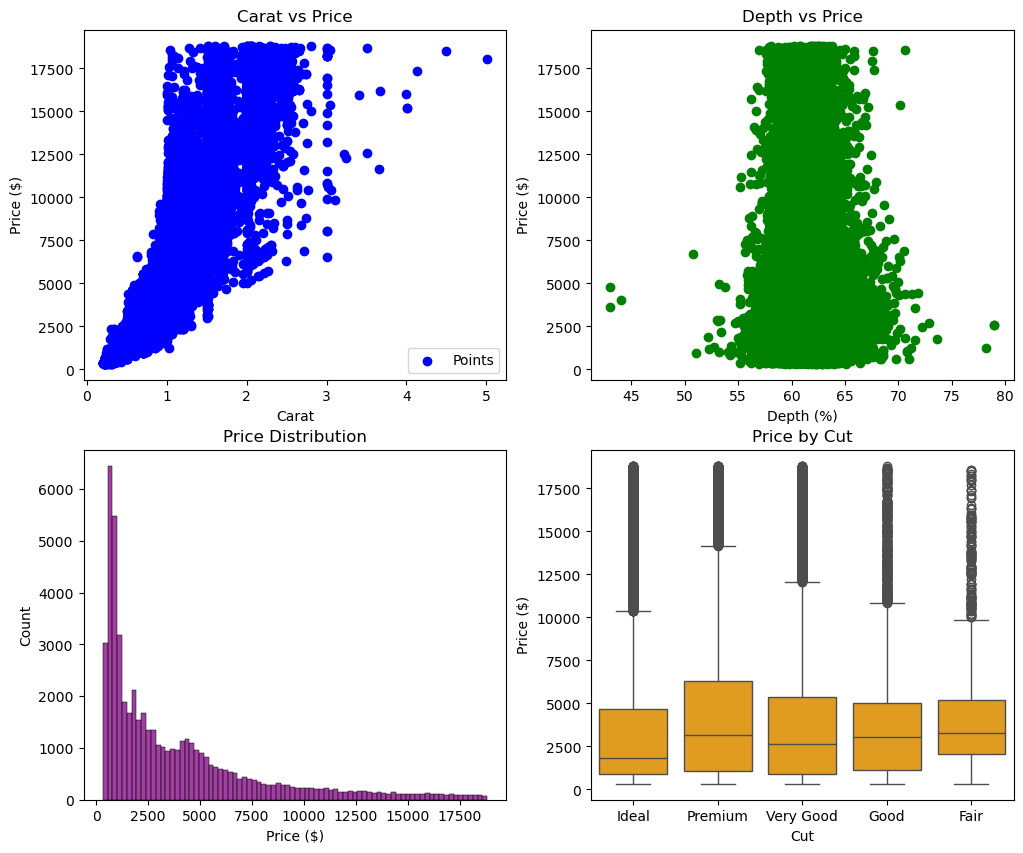

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes[0,0].scatter(diamonds_clean["carat"], diamonds_clean["price"], color="blue", label="Points")
axes[0,0].set_title("Carat vs Price")
axes[0,0].set_xlabel("Carat")
axes[0,0].set_ylabel("Price ($)")
axes[0,0].legend()

axes[0,1].scatter(diamonds_clean["depth"], diamonds_clean["price"], color="green")
axes[0,1].set_title("Depth vs Price")
axes[0,1].set_xlabel("Depth (%)")
axes[0,1].set_ylabel("Price ($)")

sns.histplot(diamonds_clean["price"], ax=axes[1,0], color="purple")
axes[1,0].set_title("Price Distribution")
axes[1,0].set_xlabel("Price ($)")
axes[1,0].set_ylabel("Count")

sns.boxplot(x="cut", y="price", data=diamonds_clean, ax=axes[1,1], color="orange")
axes[1,1].set_title("Price by Cut")
axes[1,1].set_xlabel("Cut")
axes[1,1].set_ylabel("Price ($)")

plt.show()

In [25]:
# Carat vs Price: bigger carat diamonds cost more, strong positive trend
# Chose these columns because carat is the most important factor in diamond pricing
# Bigger diamonds generally cost more. There is a strong upward trend
# showing that carat has a big impact on price.

# Depth vs Price: no clear pattern, depth does not strongly affect price
# Chose depth to see if diamond proportions impact price, 
# Depth does not clearly affect price. Points are scattered and there
# is no obvious pattern, meaning depth is not a strong price predictor.

# Price Histogram: most diamonds are cheaper, a few very expensive ones (right-skewed)
# Chose price alone to see general price distribution
# Most diamonds are lower-priced, and only a small number are very
# expensive. The distribution is right-skewed.

# Price by Cut: better cuts (Ideal/Premium) usually cost more on average
# Chose cut vs price to see effect of cut quality on price
# Higher cut grades (Ideal, Premium) tend to have higher prices on average,
# but there is still a lot of overlap between categories. Cut matters, but carat matters more.